# Exercise 2: Boosting

## Do not start the exercise until you fully understand the submission guidelines.


* The homework assignments are executed automatically. 
* Failure to comply with the following instructions will result in a significant penalty. 
* Appeals regarding your failure to read these instructions will be denied. 
* Kind reminder: the homework assignments contribute 60% of the final grade.


## Read the following instructions carefully:

1. This Jupyter notebook contains all the step-by-step instructions needed for this exercise.
1. Write **efficient**, **vectorized** code whenever possible. Some calculations in this exercise may take several minutes when implemented efficiently, and might take much longer otherwise. Unnecessary loops will result in point deductions.
1. You are responsible for the correctness of your code and should add as many tests as you see fit to this jupyter notebook. Tests will not be graded nor checked.
1. You are allowed to use functions and methods from the [Python Standard Library](https://docs.python.org/3/library/).
1. Your code must run without errors. Use at least `numpy` 1.15.4. Any code that cannot run will not be graded.
1. Write your own code. Cheating will not be tolerated.
1. Submission includes a zip file that contains this notebook, with your group number and ID as the file name. For example, `hw2_13_123456789_987654321.zip` if you submitted in pairs and `hw2_13_123456789.zip` if you submitted the exercise alone. The name of the notebook should follow the same structure.
   
Please use only a **zip** file in your submission.

---
---

## Please sign that you have read and understood the instructions: 

david.borecki@post.runi.ac.il

guy.benari@post.runi.ac.il

---
---


In [1]:
# Import necessary libraries
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

np.random.seed(42)

# Design your algorithm
Make sure to describe the algorithm, its limitations, and describe use-cases.

AdaBoost uses exponential loss $L(H) = \sum_{i=1}^{n}{ \exp(-y_i \cdot H(x_i))}$ where $y_i \in \{-1, +1\}$  (binary classifer).

We build the ensemble classifer by $H_{t+1} = H_t + \alpha h$, where $h$ is a weak learner of a  decision tree of depth 1 with $\alpha$ impact.
So $L(H_{t+1}) = \sum_{i=1}^{n} \exp(-y_i (H_t(x_i) + \alpha h(x_i))) = \sum_{i=1}^{n} \exp(-y_i H_t(x_i)) \cdot \exp(-y_i \alpha h(x_i))$
Let $w_i = \exp(-y_i H_t(x_i))$ So $$L(H_{t+1}) = \sum_{i=1}^{n} w_i \exp(-y_i \alpha h(x_i))$$

So the error term is $$\epsilon_t = \frac{\sum_{i=1}^{n} w_i \mathbb{I}(y_i \neq h(x_i))}{\sum_{i=1}^{n} w_i}$$
So after rearranging terms: $$\alpha_t = \frac{1}{2} \ln(\frac{1 - \epsilon_t}{\epsilon_t})$$

So have update rule:$$w_{i}^{(t+1)} = w_i^{(t)} \cdot \exp(-\alpha_t \cdot y_i \cdot h(x_i))$$

Normalizing all $w_i $

We will keep updating the model with new weak learners until the number of weak learners passes some threshold or unable to get weak learner with error < 0.5. Each weak learner will be picked by the split that reduces the error rate of the entire ensemble learning .

Algorithm:
Intially set all $w_i = 1/m$ for all data points.
Determine next best weak learner by looping through all feature splits
Calculate its $\alpha$ and update $H_{t+1}$
Keep updating until reach number of weak learners or unable to find good enough weak learner. 

predict by $H(x)$ sign.


Therefore hyperparameters are 
- Number of weak learners (stumps)

Limitations:
- Training can't be parallelized as is sequential in construction
-  Sensitivity to outliers due to exponential loss which leads to larger weight


Use cases:
- Binary classifcation
- ...



# Your implementations
You may add new cells, write helper functions or test code as you see fit.
Please use the cell below and include a description of your implementation.
Explain code design consideration, algorithmic choices and any other details you think is relevant to understanding your implementation.
Failing to explain your code will lead to point deductions.

## Implementation Details

The `AdaBoostCustom` class implements discrete AdaBoost from scratch:

- **Weak learner selection** (`_best_stump`): Exhaustively searches all features and all unique thresholds to find the stump minimizing weighted classification error. If a stump's error exceeds 0.5, we flip its polarity (multiply predictions by $-1$) so it becomes useful.
- **Weight updates**: After each round, sample weights are updated via $w_i \leftarrow w_i \cdot \exp(-\alpha_t \cdot y_i \cdot h_t(x_i))$ and renormalized. This upweights misclassified samples for the next round.
- **Early stopping**: Training halts if no stump achieves error $< 0.5$, meaning no useful weak learner exists.
- **Prediction**: Final classification is $\text{sign}\left(\sum_t \alpha_t \cdot h_t(x)\right)$.
- **Data stored as `dtype=object`**: Allows handling of both numeric and categorical features in a unified way.
- **Numerical stability**: $\epsilon_t$ is clamped to a minimum of $10^{-10}$ to avoid division by zero in the $\alpha$ calculation.

In [2]:
import numpy as np

class AdaBoostCustom:
    def __init__(self, T):
        self.T = T
        self.alphas = []
        self.models = []

    def _best_stump(self, X, y, w):
        n_samples, n_features = X.shape
        best_err = float('inf')
        best_feat, best_thresh, best_pol, best_is_cat = None, None, None, None

        for feat in range(n_features):
            col = X[:, feat]
            try:
                col.astype(float)
                is_categorical = False
            except (ValueError, TypeError):
                is_categorical = True

            potential_threshold = np.unique(col)

            for cand in potential_threshold:
                if is_categorical:
                    preds = np.where(col == cand, +1, -1)
                else:
                    preds = np.where(col.astype(float) <= float(cand), +1, -1)
                err = np.sum(w[preds != y]) / np.sum(w)

                if err > 0.5:
                    err = 1 - err
                    polarity = -1
                else:
                    polarity = +1

                if err < best_err:
                    best_err   = err
                    best_feat  = feat
                    best_thresh = cand
                    best_pol   = polarity
                    best_is_cat = is_categorical

        return best_feat, best_thresh, best_pol, best_is_cat, best_err

    def _stump_predict(self, X, model):
        feat, thresh, polarity, is_categorical = model
        col = X[:, feat]
        if is_categorical:
            return np.where(col == thresh, polarity, -polarity)
        else:
            return np.where(col.astype(float) <= float(thresh), polarity, -polarity)

    def fit(self, X, y, categorical_features=None):
        X = np.array(X, dtype=object)
        y = np.array(y, dtype=float)
        n, d = X.shape

        w = np.full(n, 1.0 / n)

        for t in range(self.T):
            feat, thresh, polarity, is_cat, eps = self._best_stump(X, y, w)

            if eps >= 0.5:
                break

            eps   = max(eps, 1e-10)
            alpha = 0.5 * np.log((1.0 - eps) / eps)

            model = (feat, thresh, polarity, is_cat)
            self.models.append(model)
            self.alphas.append(alpha)

            preds = self._stump_predict(X, model)
            w = w * np.exp(-alpha * y * preds)
            w /= w.sum()

    def predict(self, X):
        X = np.array(X, dtype=object)
        H = sum(
            alpha * self._stump_predict(X, model)
            for alpha, model in zip(self.alphas, self.models)
        )
        return np.sign(H)

# Generate data
Please use the cell below to discuss your dataset choice and why it is appropriate (or not) for this algorithm.

The make_moons dataset from sklearn will indicate the effectiveness and correct implentation of the AdaBoost algorithm. This is because the data is inherently non-linear so regular learners and weak learners will struggle but with AdaBoost creating stumps each stump will achieve error rate below 50% but with all of them combined a much higher accuracy should be achievable.

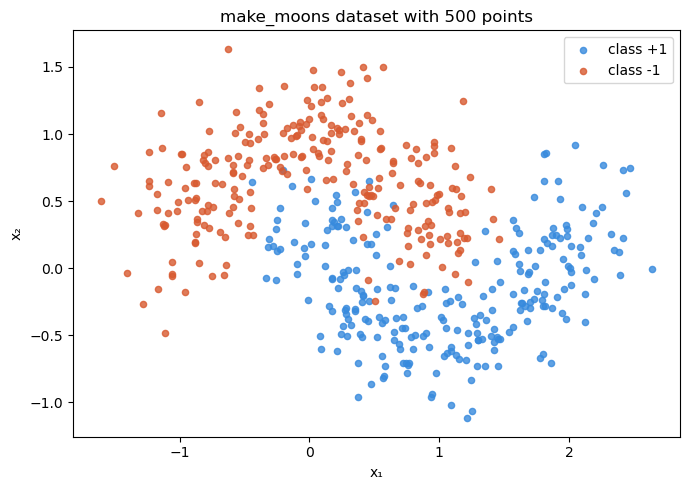

In [3]:
# Your code here
from sklearn.datasets import make_moons
X, y = make_moons(n_samples=500, noise=0.25, random_state=42)
y = np.where(y == 0, -1, +1)


plt.figure(figsize=(7, 5))
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='#378ADD', s=20, label='class +1', alpha=0.8)
plt.scatter(X[y == -1, 0], X[y == -1, 1], c='#D85A30', s=20, label='class -1', alpha=0.8)
plt.legend()
plt.xlabel('x₁')
plt.ylabel('x₂')
plt.title('make_moons dataset with 500 points')
plt.tight_layout()
plt.show()


# AdaBoost demonstration 
Demonstrate your AdaBoost implementation.

Add plots and figures. 

Please use the cell below to describe your results and tests.

Describe the difference between your implementation and the sklearn implementation. Hint: you can look at the documentation.

The final accuracy on the test set of the custom implementation is 0.05 worse than the sklearn implentation. Consdiring sklearn defaults to depth 1 decision trees like the custom version, this difference is likely due to the thresholds of the decision trees as sklearn uses the midpoint between training points whereas the custom only uses points in the train data. 

The final decision boundary shows that the sklearn model is a more complex decision boundary compared to the custom model. This decision boundary difference is more observable for values x1 >0 where we can see the custom model horizontal boundary is more straight whereas the skelearn has multiple rises.

It can be seen that the test and train accuracy of the custom model have similiar shape and both osciliate over time but appear to have a general upward trend. The gap between train and test accuracy appears relatively constant. AdaBoost should have monotonically non-decreasing accuracy on the training data, likely the cause of this oscilation is alphas being too large when added and constraining there size would reduce this flaw.

A  possible reason for the difference in perofrmance between sklearn and the custom version are that the custom code uses lassic discrete AdaBoost (SAMME) whereas sklearn uses SAMME.R, where sklearn is using the probability of being in classes whereas the custom is using a binary distinction.

Plot used:
- Final Decision Boundary Comparison 
- Custom decision boundary over time (as more stumps added)
- Custom accuracy vs number of stumps 

Custom  accuracy: 0.88
Sklearn accuracy: 0.93


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


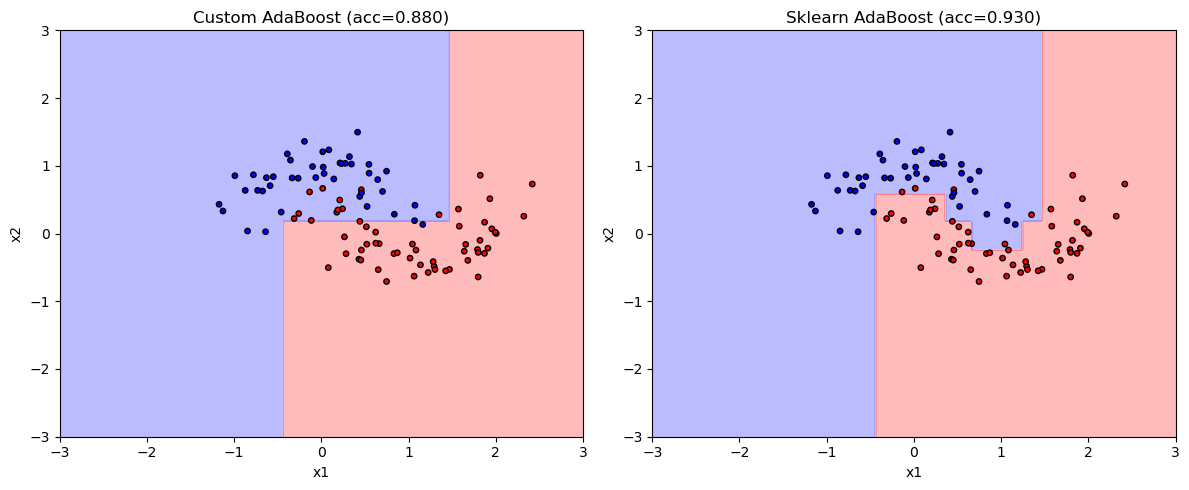

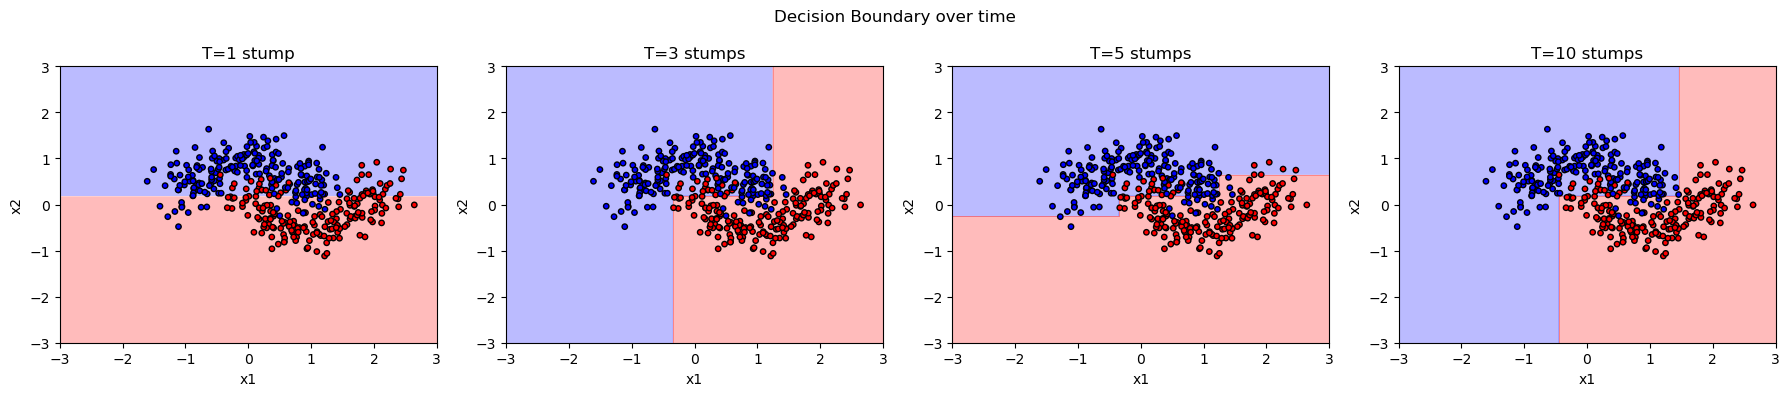

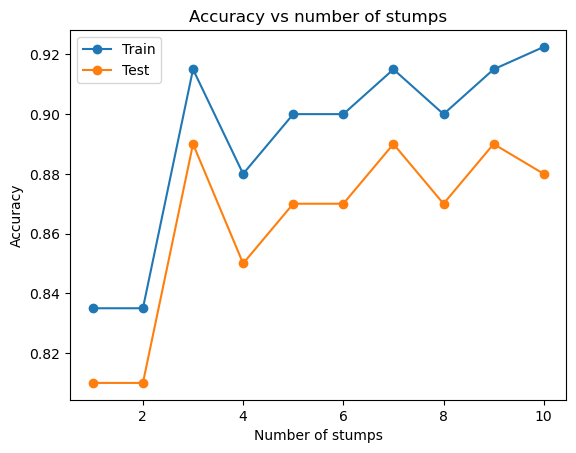

In [4]:
custom_model = AdaBoostCustom(T=10)
sklearn_model = AdaBoostClassifier(n_estimators=10, random_state=42)

# Your code here

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

custom_model.fit(X_train, y_train)
sklearn_model.fit(X_train, np.where(y_train == -1, 0, 1))  


custom_preds  = custom_model.predict(X_test)
sklearn_preds = np.where(sklearn_model.predict(X_test) == 0, -1, 1)

print(f"Custom  accuracy: {(y_test == custom_preds).sum()/len(y_test)}")
print(f"Sklearn accuracy: {(y_test == sklearn_preds).sum()/len(y_test)}")





#Final Decision Boundaries 

xx, yy = np.meshgrid(np.linspace(-3, 3, 300), np.linspace(-3, 3, 300))
grid = np.c_[xx.ravel(), yy.ravel()]

custom_zz  = custom_model.predict(grid).reshape(xx.shape)
sklearn_zz = np.where(sklearn_model.predict(grid) == 0, -1, 1).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, zz, preds, title in zip(
    axes,
    [custom_zz, sklearn_zz],
    [custom_preds, sklearn_preds],
    ["Custom AdaBoost", "Sklearn AdaBoost"]
):
    acc = (y_test == preds).sum() / len(y_test)
    ax.contourf(xx, yy, zz, alpha=0.3, cmap='bwr')
    ax.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='bwr', edgecolors='k', s=15)
    ax.set_title(f"{title} (acc={acc:.3f})")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()




# Stumps over time 
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
fig.suptitle("Decision Boundary over time")
for ax, t in zip(axes, [1, 3, 5, 10]):
    H = sum(
        alpha * custom_model._stump_predict(grid, m)
        for alpha, m in zip(custom_model.alphas[:t], custom_model.models[:t])
    )
    ax.contourf(xx, yy, np.sign(H).reshape(xx.shape), alpha=0.3, cmap='bwr')
    ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', edgecolors='k', s=15)
    ax.set_title(f"T={t} stump{'s' if t > 1 else ''}")
    ax.set_xlabel("x1")
    ax.set_ylabel("x2")

plt.tight_layout()
plt.show()


# T over time accuracy 
H_train = np.zeros(len(y_train))
H_test  = np.zeros(len(y_test))
train_accs, test_accs = [], []

for alpha, model in zip(custom_model.alphas, custom_model.models):
    H_train += alpha * custom_model._stump_predict(X_train, model)
    H_test  += alpha * custom_model._stump_predict(X_test,  model)
    train_accs.append((np.sign(H_train) == y_train).mean())
    test_accs.append((np.sign(H_test)  == y_test).mean())
    
    
plt.plot(range(1, len(train_accs) + 1), train_accs, label='Train', marker='o')
plt.plot(range(1, len(test_accs)  + 1), test_accs,  label='Test',  marker='o')
plt.title("Accuracy vs number of stumps")
plt.xlabel("Number of stumps")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Generate additional data sets
Generate at least two experimental datasets with binary labels, designed to demonstrate specific properties of AdaBoost (e.g., handling noise or overfitting).

Add plots and figures.

Please use the cell below to describe your suggested approach in detail. Use formal notations where appropriate.

Describe and discuss your results.



We design two datasets, each targeting a specific known property of AdaBoost:

- Dataset 1: XOR Pattern (non-linear boundary via axis-aligned stumps)
The XOR pattern assigns labels based on $y = {sign}(x_1 \cdot x_2)$. Points in the top-right and bottom-left quadrants get label $+1$; points in the top-left and bottom-right get $-1$. Therefore this will be a non-linear boundary that no depth 1 decision can solve as it can only make an axis aligned, but XOR requires cuts on both axes. This is an example of a non-linear problem AdaBoost will still struggle with unless a lot more learners used. 

- Dataset 2: Noisy Data (sensitivity to outliers)
Using sklearns `make_blobs` which are easily seperable but then flipping 20% of the datat points will introduce noise into an otherwise linearly seperable dataset. AdaBoost will overfit to the noisy points leading to weaker test accuracy, This will demonstrate a potential. limitation of the model 

Both datasets use 2000 samples and 2 features for easy visualization.

In [5]:

# Dataset 1: XOR Pattern


X_xor = np.random.randn(5000, 2)
y_xor = np.where(X_xor[:, 0] * X_xor[:, 1] > 0, +1, -1)

X_xor_train, X_xor_test, y_xor_train, y_xor_test = train_test_split(
    X_xor, y_xor, test_size=0.2, random_state=42
)


# Dataset 2: Noisy Labels (20% label flipping)

X_noisy, y_noisy = make_moons(
    n_samples=5000, noise=0.1, random_state=42
)

# make y -1 and 1
y_noisy = np.where(y_noisy == 0, -1, +1)

# swap 20% of labels
rng = np.random.default_rng(42)
noise_rate = 0.1
n_flip = int(len(y_noisy) * noise_rate)
flip_idx = rng.choice(len(y_noisy), size=n_flip, replace=False)
y_noisy[flip_idx] *= -1

X_noisy_train, X_noisy_test, y_noisy_train, y_noisy_test = train_test_split(
    X_noisy, y_noisy, test_size=0.2, random_state=42
)

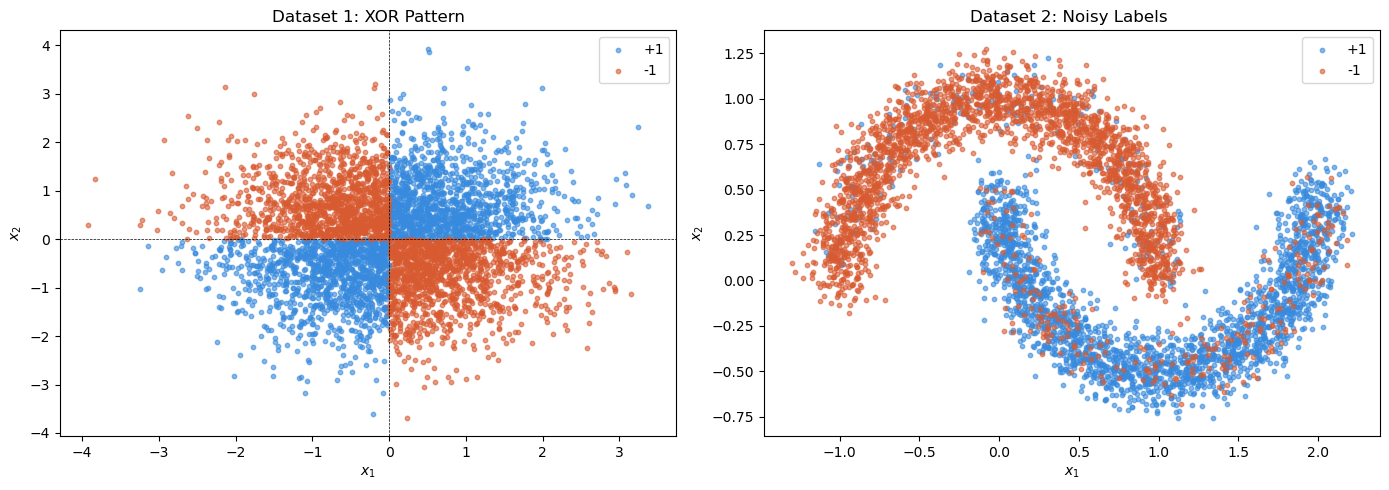

In [6]:
# Visualize data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# XOR
ax = axes[0]
ax.scatter(X_xor[y_xor == 1, 0], X_xor[y_xor == 1, 1], c='#378ADD', s=10, alpha=0.6, label='+1')
ax.scatter(X_xor[y_xor == -1, 0], X_xor[y_xor == -1, 1], c='#D85A30', s=10, alpha=0.6, label='-1')
ax.axhline(0, color='k', linewidth=0.5, linestyle='--')
ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
ax.set_title('Dataset 1: XOR Pattern')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()

# Noisy
ax = axes[1]
ax.scatter(X_noisy[y_noisy == 1, 0], X_noisy[y_noisy == 1, 1], c='#378ADD', s=10, alpha=0.6, label='+1')
ax.scatter(X_noisy[y_noisy == -1, 0], X_noisy[y_noisy == -1, 1], c='#D85A30', s=10, alpha=0.6, label='-1')
ax.set_title('Dataset 2: Noisy Labels ')
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.legend()

plt.tight_layout()
plt.show()



# Test algorithms
Test your AdaBoost, a library implementation of AdaBoost and at least two additional models, one of which must be another boosting algorithm on your two datasets.

Add plots and figures.

Please use the cell below to describe your suggested approach in detail. Use formal notations where appropriate.

Describe and discuss your results.

### Experiments
4 Models for Comparison
1. AdaBoost Custom
2. AdaBoost Sklearn 
3. Gradient Boosting 
4. Random Forest 

Hyperparameters: 2 Experiment using varied number of estimators across difficult datasets for AdaBoost.

1st Experiment: XOR dataset using varied number of estimators
- Number of estimators T: $T \in \{1, 3, 5, 10, 20, 50, 100\}$
- Since AdaBoost uses depth 1 decision tree set max_depth for all models = 1 

2nd Experiment:  Outlier dataset using varied number of estimators
- Number of estimators T: $T \in \{1, 3, 5, 10, 20, 50, 100, 200\}$
- Since AdaBoost uses depth 1 decision tree set max_depth for all models = 1 

3rd Experiment: using Outlier and XOR dataset to compare how different weak learners base impacts outcome.

-  Number of estimators for Models $T =20$
- AdaBoost with weak learners of depth 1 fixed 
- max_depth of Gradient boosting and RandomForestClassifer [1,2,3]


We will use accuracy on test and train set as the performance metric as it measures how well the models predict the data and also how much the models are overfitting the training data Both datasets are balanced (equal class sizes), so accuracy is a fair and unbiased measure. 

Expected Outcomes
-1st Experiment (XOR): The algorithms should all struggle with the XOR dataset as it is inherently difficult for boosting algorithms but we expect minor improvmenets with increased number of estimators. 
-2nd Experiment (outliers): The best model performance should be aroudn 0.9 accuracy due to 20% of data points being noise and expect the increase in number of estiamtors to lead the trainign accuracy to continuously fallign but at some point the model test accuracy should fall due to overfitting.

-3rd Experiment (Depth); The models with greater depth (more complex) weak learners should perform better on the XOR dataset but may encounter overfitting or not as good results on the outlier data.


In [7]:
#Experiment 1: XOR 
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

# Hyperparameters to test
T_values = [1, 3, 5, 10, 20, 50, 100]


def build_models(T, max_depth=1):
    return {
        'AdaBoost (Custom)': AdaBoostCustom(T=T),
        'AdaBoost (sklearn)': AdaBoostClassifier(n_estimators=T, random_state=42),
        'GradientBoosting': GradientBoostingClassifier(n_estimators=T, max_depth=max_depth, random_state=42),
        'RandomForest': RandomForestClassifier(n_estimators=T, max_depth=max_depth, random_state=42),
    }


results_e1 ={}

for T in T_values:
    models = build_models(T, max_depth=1)
    for model_name, model in models.items():
        if model_name not in results_e1:
            results_e1[model_name] = {'acc_train': [], 'acc_test': []}
        
        model.fit(X_xor_train, y_xor_train)
        preds_train = model.predict(X_xor_train)
        preds_test = model.predict(X_xor_test)
        
        results_e1[model_name]['acc_train'].append(accuracy_score(y_xor_train, preds_train))
        results_e1[model_name]['acc_test'].append(accuracy_score(y_xor_test, preds_test))
# results_e1

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/ana

In [9]:
#Experiment 2: Outlier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score

# Hyperparameters to test
T_values = [1, 3, 5, 10, 20, 50, 100, 150]

def build_models(T, max_depth=1):
    return {
        'AdaBoost (Custom)': AdaBoostCustom(T=T),
        'AdaBoost (sklearn)': AdaBoostClassifier(n_estimators=T, random_state=42),
        'GradientBoosting': GradientBoostingClassifier(n_estimators=T, max_depth=max_depth, random_state=42),
        'RandomForest': RandomForestClassifier(n_estimators=T, max_depth=max_depth, random_state=42),
    }


results_e2 ={}


for T in T_values:
    models = build_models(T, max_depth=1)
    for model_name, model in models.items():
        if model_name not in results_e2:
            results_e2[model_name] = {'acc_train': [], 'acc_test': []}
        
        model.fit(X_noisy_train, y_noisy_train)
        preds_train = model.predict(X_noisy_train)
        preds_test = model.predict(X_noisy_test)
        
        results_e2[model_name]['acc_train'].append(accuracy_score(y_noisy_train, preds_train))
        results_e2[model_name]['acc_test'].append(accuracy_score(y_noisy_test, preds_test))
# results_e2



/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
/opt/ana

In [11]:

from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score



T = 20
depth_values = [1, 2, 3]


results_e3_xor = {
    'AdaBoost (Custom)': {'acc_train': [], 'acc_test': []},
    'AdaBoost (sklearn)': {'acc_train': [], 'acc_test': []},
    'GradientBoosting': {d: {'acc_train': None, 'acc_test': None} for d in depth_values},
    'RandomForest': {d: {'acc_train': None, 'acc_test': None} for d in depth_values}
}


ada_custom = AdaBoostCustom(T=T)
ada_custom.fit(X_xor_train, y_xor_train)
results_e3_xor['AdaBoost (Custom)']['acc_train'] = accuracy_score(y_xor_train, ada_custom.predict(X_xor_train))
results_e3_xor['AdaBoost (Custom)']['acc_test'] = accuracy_score(y_xor_test, ada_custom.predict(X_xor_test))


ada_sklearn = AdaBoostClassifier(n_estimators=T, random_state=42)
ada_sklearn.fit(X_xor_train, y_xor_train)
results_e3_xor['AdaBoost (sklearn)']['acc_train'] = accuracy_score(y_xor_train, ada_sklearn.predict(X_xor_train))
results_e3_xor['AdaBoost (sklearn)']['acc_test'] = accuracy_score(y_xor_test, ada_sklearn.predict(X_xor_test))


for depth in depth_values:

    gb_model = GradientBoostingClassifier(n_estimators=T, max_depth=depth, random_state=42)
    rf_model = RandomForestClassifier(n_estimators=T, max_depth=depth, random_state=42)
    

    gb_model.fit(X_xor_train, y_xor_train)
    results_e3_xor['GradientBoosting'][depth]['acc_train'] = accuracy_score(y_xor_train, gb_model.predict(X_xor_train))
    results_e3_xor['GradientBoosting'][depth]['acc_test'] = accuracy_score(y_xor_test, gb_model.predict(X_xor_test))
    

    rf_model.fit(X_xor_train, y_xor_train)
    results_e3_xor['RandomForest'][depth]['acc_train'] = accuracy_score(y_xor_train, rf_model.predict(X_xor_train))
    results_e3_xor['RandomForest'][depth]['acc_test'] = accuracy_score(y_xor_test, rf_model.predict(X_xor_test))

print("XOR Experiment Execution Complete.")

T = 20
depth_values = [1, 2, 3]

results_e3_outlier = {
    'AdaBoost (Custom)': {'acc_train': [], 'acc_test': []},
    'AdaBoost (sklearn)': {'acc_train': [], 'acc_test': []},
    'GradientBoosting': {d: {'acc_train': None, 'acc_test': None} for d in depth_values},
    'RandomForest': {d: {'acc_train': None, 'acc_test': None} for d in depth_values}
}


ada_custom = AdaBoostCustom(T=T)
ada_custom.fit(X_noisy_train, y_noisy_train)
results_e3_outlier['AdaBoost (Custom)']['acc_train'] = accuracy_score(y_noisy_train, ada_custom.predict(X_noisy_train))
results_e3_outlier['AdaBoost (Custom)']['acc_test'] = accuracy_score(y_noisy_test, ada_custom.predict(X_noisy_test))


ada_sklearn = AdaBoostClassifier(n_estimators=T, random_state=42)
ada_sklearn.fit(X_noisy_train, y_noisy_train)
results_e3_outlier['AdaBoost (sklearn)']['acc_train'] = accuracy_score(y_noisy_train, ada_sklearn.predict(X_noisy_train))
results_e3_outlier['AdaBoost (sklearn)']['acc_test'] = accuracy_score(y_noisy_test, ada_sklearn.predict(X_noisy_test))



for depth in depth_values:

    gb_model = GradientBoostingClassifier(n_estimators=T, max_depth=depth, random_state=42)
    rf_model = RandomForestClassifier(n_estimators=T, max_depth=depth, random_state=42)
    

    gb_model.fit(X_noisy_train, y_noisy_train)
    results_e3_outlier['GradientBoosting'][depth]['acc_train'] = accuracy_score(y_noisy_train, gb_model.predict(X_noisy_train))
    results_e3_outlier['GradientBoosting'][depth]['acc_test'] = accuracy_score(y_noisy_test, gb_model.predict(X_noisy_test))
    

    rf_model.fit(X_noisy_train, y_noisy_train)
    results_e3_outlier['RandomForest'][depth]['acc_train'] = accuracy_score(y_noisy_train, rf_model.predict(X_noisy_train))
    results_e3_outlier['RandomForest'][depth]['acc_test'] = accuracy_score(y_noisy_test, rf_model.predict(X_noisy_test))

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


XOR Experiment Execution Complete.


/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


ValueError: x and y must have same first dimension, but have shapes (8,) and (7,)

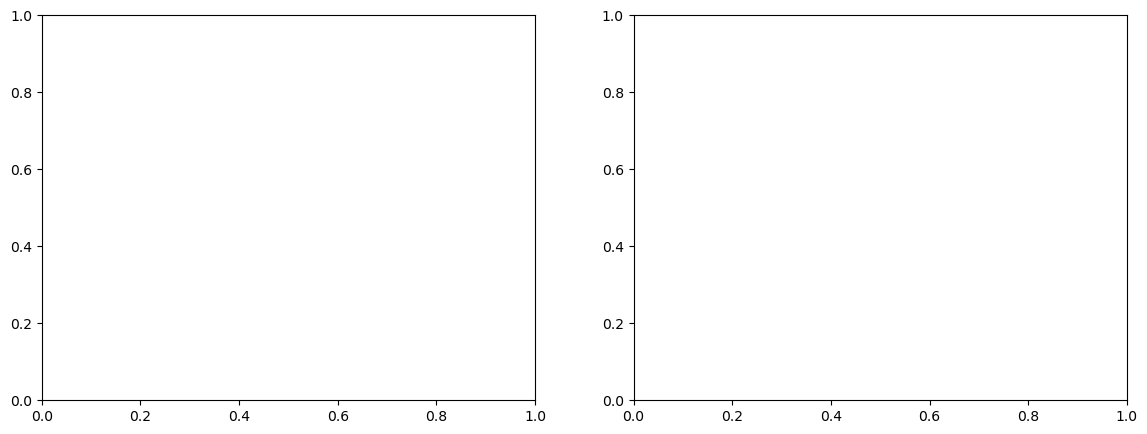

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'AdaBoost (Custom)': '#D85A30', 'AdaBoost (sklearn)': '#E8943A',
          'GradientBoosting': '#378ADD', 'RandomForest': '#2EAD4B'}
markers = {'AdaBoost (Custom)': 'o', 'AdaBoost (sklearn)': 's',
           'GradientBoosting': '^', 'RandomForest': 'D'}
linestyles = {'AdaBoost (Custom)': '-', 'AdaBoost (sklearn)': '--',
              'GradientBoosting': '-.', 'RandomForest': ':'}
ax = axes[0]
for model_name in results_e1:
    ax.plot(T_values, results_e1[model_name]['acc_test'],
            label=model_name, color=colors[model_name],
            marker=markers[model_name], linestyle=linestyles[model_name],)
ax.set_title(f'XOR — Test Accuracy vs T')
ax.set_xlabel('Number of estimators (T)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)


ax = axes[1]
for model_name in results_e1:
    ax.plot(T_values, results_e1[model_name]['acc_train'],
            label=model_name, color=colors[model_name],
            marker=markers[model_name], linestyle=linestyles[model_name],)
ax.set_title(f'XOR — Train Accuracy vs T')
ax.set_xlabel('Number of estimators (T)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

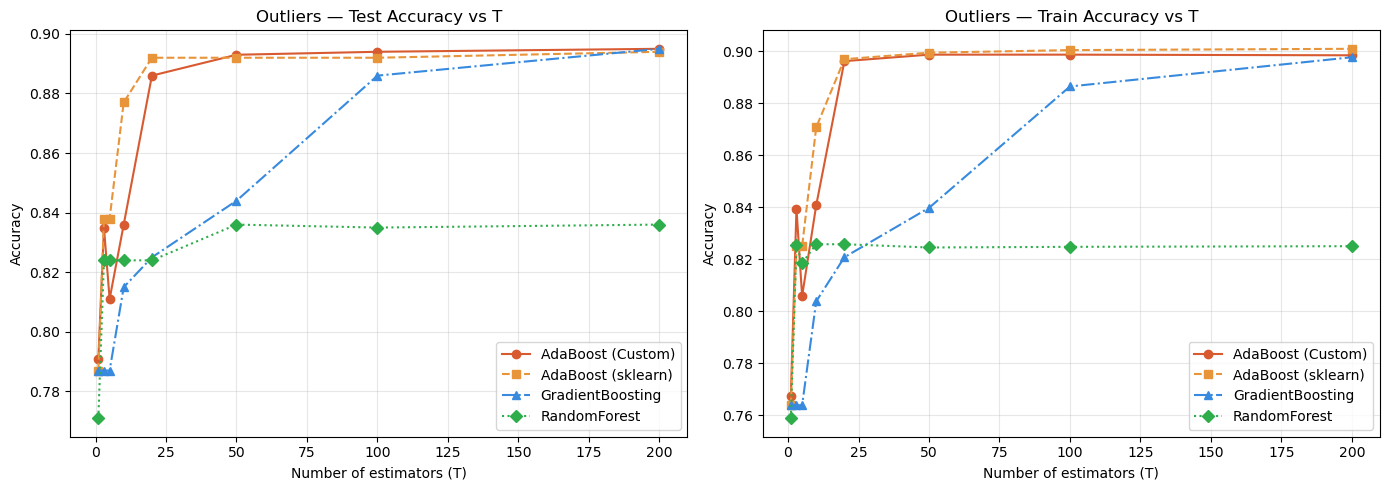

In [ ]:

# ============================================================
# Plot Experiment 2: Outliers — Accuracy vs T
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = {'AdaBoost (Custom)': '#D85A30', 'AdaBoost (sklearn)': '#E8943A',
          'GradientBoosting': '#378ADD', 'RandomForest': '#2EAD4B'}
markers = {'AdaBoost (Custom)': 'o', 'AdaBoost (sklearn)': 's',
           'GradientBoosting': '^', 'RandomForest': 'D'}
linestyles = {'AdaBoost (Custom)': '-', 'AdaBoost (sklearn)': '--',
              'GradientBoosting': '-.', 'RandomForest': ':'}


ax = axes[0]
for model_name in results_e2:  # Swapped to results_e2
    ax.plot(T_values, results_e2[model_name]['acc_test'],  # Swapped to results_e2
            label=model_name, color=colors[model_name],
            marker=markers[model_name], linestyle=linestyles[model_name])
ax.set_title('Outliers — Test Accuracy vs T')  # Updated title
ax.set_xlabel('Number of estimators (T)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
for model_name in results_e2:  
    ax.plot(T_values, results_e2[model_name]['acc_train'],  
            label=model_name, color=colors[model_name],
            marker=markers[model_name], linestyle=linestyles[model_name])
ax.set_title('Outliers — Train Accuracy vs T')  
ax.set_xlabel('Number of estimators (T)')
ax.set_ylabel('Accuracy')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

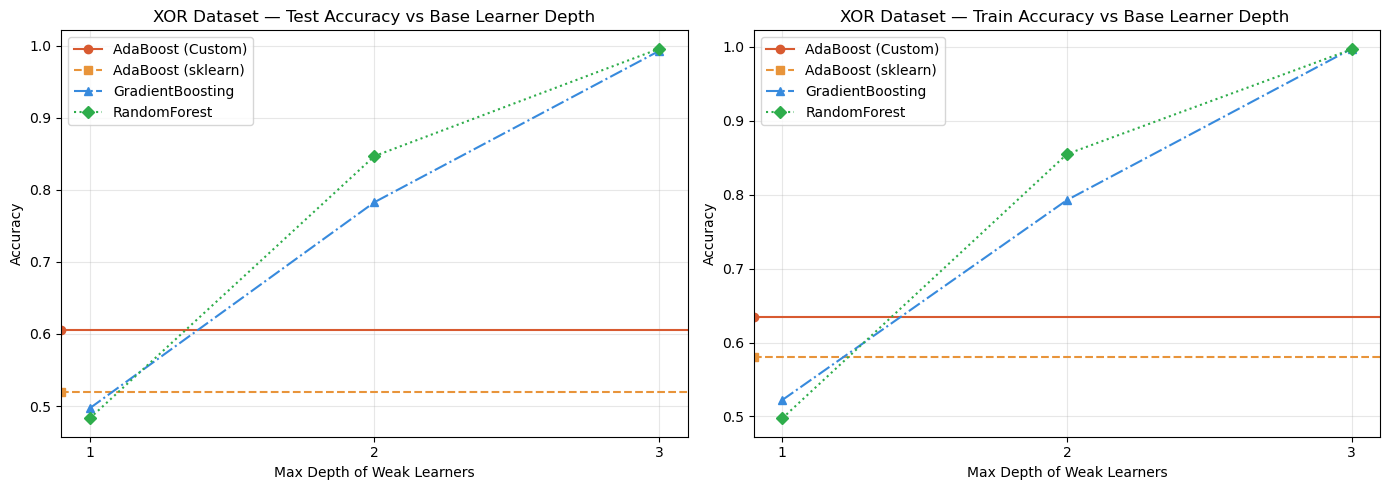

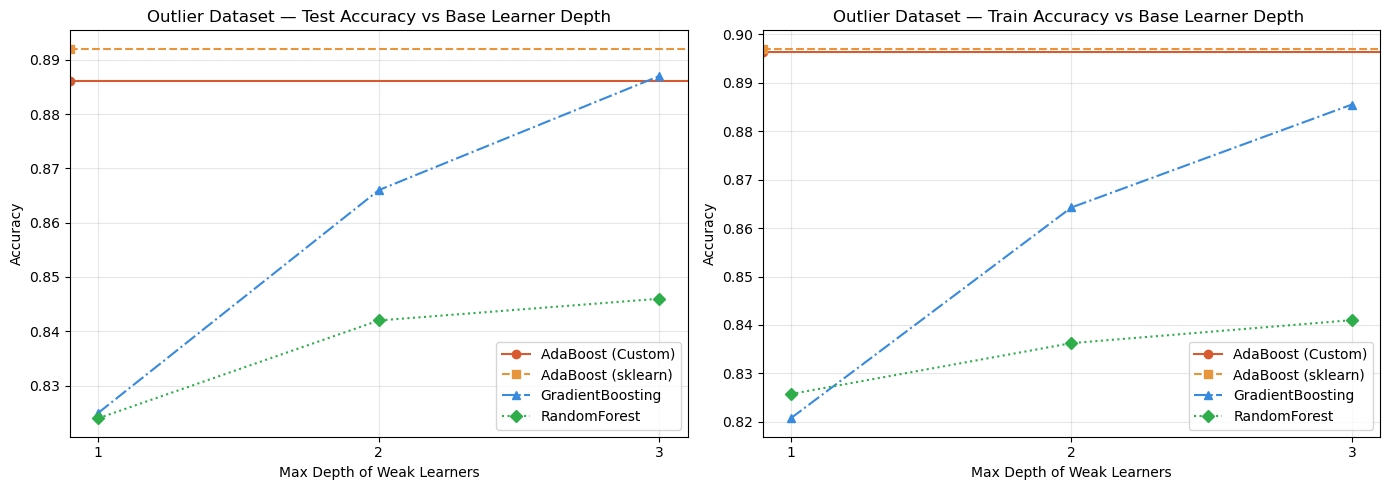

In [13]:

def plot_e3(results_e3, dataset):
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))


        colors = {
        'AdaBoost (Custom)': '#D85A30', 
        'AdaBoost (sklearn)': '#E8943A',
        'GradientBoosting': '#378ADD', 
        'RandomForest': '#2EAD4B'
        }
        markers = {
        'AdaBoost (Custom)': 'o', 
        'AdaBoost (sklearn)': 's',
        'GradientBoosting': '^', 
        'RandomForest': 'D'
        }
        linestyles = {
        'AdaBoost (Custom)': '-', 
        'AdaBoost (sklearn)': '--',
        'GradientBoosting': '-.', 
        'RandomForest': ':'
        }

        depth_values = [1, 2, 3]


        ax = axes[0]


        ax.axhline(y=results_e3['AdaBoost (Custom)']['acc_test'], 
                color=colors['AdaBoost (Custom)'], linestyle=linestyles['AdaBoost (Custom)'],
                label='AdaBoost (Custom)', marker=markers['AdaBoost (Custom)'], markevery=[0])

        ax.axhline(y=results_e3['AdaBoost (sklearn)']['acc_test'], 
                color=colors['AdaBoost (sklearn)'], linestyle=linestyles['AdaBoost (sklearn)'],
                label='AdaBoost (sklearn)', marker=markers['AdaBoost (sklearn)'], markevery=[0])


        gb_test_accs = [results_e3['GradientBoosting'][d]['acc_test'] for d in depth_values]
        rf_test_accs = [results_e3['RandomForest'][d]['acc_test'] for d in depth_values]

        ax.plot(depth_values, gb_test_accs, label='GradientBoosting', 
                color=colors['GradientBoosting'], marker=markers['GradientBoosting'], linestyle=linestyles['GradientBoosting'])

        ax.plot(depth_values, rf_test_accs, label='RandomForest', 
                color=colors['RandomForest'], marker=markers['RandomForest'], linestyle=linestyles['RandomForest'])

        ax.set_title(f'{dataset} Dataset — Test Accuracy vs Base Learner Depth')
        ax.set_xlabel('Max Depth of Weak Learners')
        ax.set_ylabel('Accuracy')
        ax.set_xticks(depth_values)
        ax.legend()
        ax.grid(True, alpha=0.3)



        ax = axes[1]


        ax.axhline(y=results_e3['AdaBoost (Custom)']['acc_train'], 
                color=colors['AdaBoost (Custom)'], linestyle=linestyles['AdaBoost (Custom)'],
                label='AdaBoost (Custom)', marker=markers['AdaBoost (Custom)'], markevery=[0])

        ax.axhline(y=results_e3['AdaBoost (sklearn)']['acc_train'], 
                color=colors['AdaBoost (sklearn)'], linestyle=linestyles['AdaBoost (sklearn)'],
                label='AdaBoost (sklearn)', marker=markers['AdaBoost (sklearn)'], markevery=[0])


        gb_train_accs = [results_e3['GradientBoosting'][d]['acc_train'] for d in depth_values]
        rf_train_accs = [results_e3['RandomForest'][d]['acc_train'] for d in depth_values]

        ax.plot(depth_values, gb_train_accs, label='GradientBoosting', 
                color=colors['GradientBoosting'], marker=markers['GradientBoosting'], linestyle=linestyles['GradientBoosting'])

        ax.plot(depth_values, rf_train_accs, label='RandomForest', 
                color=colors['RandomForest'], marker=markers['RandomForest'], linestyle=linestyles['RandomForest'])

        ax.set_title(f'{dataset} Dataset — Train Accuracy vs Base Learner Depth ')
        ax.set_xlabel('Max Depth of Weak Learners')
        ax.set_ylabel('Accuracy')
        ax.set_xticks(depth_values)
        ax.legend()
        ax.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()
        
plot_e3(results_e3_xor, 'XOR')
plot_e3(results_e3_outlier, 'Outlier')


### Results Discussion. 

##### Experiment 1: XOR 
Both the train and test accuracies for all models was relatively poor on the XOR dataset regardless of the number of estimators. This is likely because weaker learners of depth 1 are too primitive to resolve XOR datasets even with different ensemble learning boosting techniques. Interestingly the AdaBoost was the best on this data for the majority of number of estimators in both the test and train accuracy.  Interestingly all models (except the random forest) achieved their best test accuracy in 20 or less number of estimators suggesting a level of overfitting after this point. 
Notably RandomForest and Gradient boosting were consistently the worst performing becuase due to thedepth of weak learners =1, a single perpendicular slice 
through a centered XOR grid splits the binary classes into a perfect 50/50 ratio, the error rate will therefore plateaus  at $\epsilon = 0.5$. This suggests while these models may have more complexity they are limited by the weak learners they are built on.


##### Experiment 2: Outliers 
This plot demonstrates how increasing the number of estimators can improve performance on both the train and test sets but can also leads to overfitting. All models perofrmance on the test set imrpoved up to 100 number of estimators indicating a more complex and higher acuracy model. However, at 200 number of estimators AdaBoost test accuracy dropped suggesting overfitting. All the models ultimately achieved test accuracy greater than 0.8 with varying speeds of convergence to their best test accuracy. RandomForest was relatively flat after 10 number of estiamtors where as adaboost (in both sklearn and custom model) converged to a test accuracy around 90Z% much quicker. GradientBoosting converge to a similiar ~90% test accuracy but requried more number of estimators to make improvements. 

##### Experiment 3: Depth of weak learners
These plots show how increasing the complexity of the weak learners can improve results on more complex data structures such as XOR but also don't always improve results over methods such as AdaBoost and may lead to overfitting. We can see that even with max depth 3 the adaboost algorithm outperforms both Gradeint boosting and RandomForests test accuracy on the outlier data. However, on the XOR data the model with depth >=2 immedtialety outperform lower depth models due to the nature of the data and ability of the model.


# Use of generative AI
Please use the cell below to describe your use of generative AI in this assignment. 

## Generative AI Usage Report

We used generative AI tools (ChatGPT /Calude Kiro) throughout this assignment in the following ways:

- Helped with writing and debugging code, including the AdaBoost implementation, dataset generation, experiment loops, and plotting. We reviewed and understood all generated code before including it.
-  Used to research various algorithms (AdaBoost, GradientBoosting, RandomForest), their hyperparameters, sklearn library APIs, and the theoretical properties of each method.
- Used to help write markdown explanations and analysis text in a clear and concise manner.
- Evaluated logic and understanding  through chat conversations with AI models. Such as determining the best possible plot methodology and datasets that could demonstrate specific attributes of boosting. 